In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

Using TensorFlow backend.
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/t

In [2]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [3]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [4]:



data = awgn(data, snr_range)

In [ ]:
print(data)

In [5]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)
augmented_sample = apply_random_noise(augmented_sample, noise_level)


In [6]:
augmented_sample.shape

(5000, 8192)

In [7]:
data=augmented_sample

In [12]:
data.shape

(5000, 8192)

/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


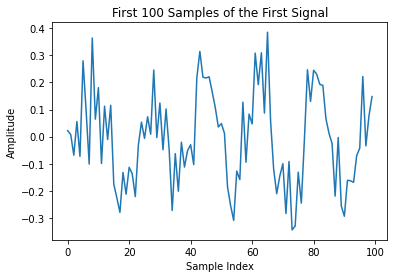

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = data  # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


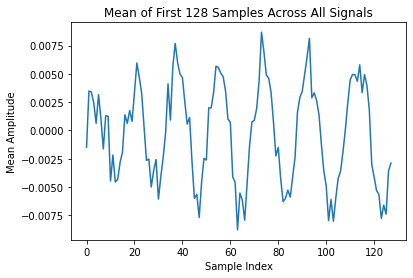

Suspected Preamble: [-1.48222550e-03+1.05147633e-03j  3.48566566e-03+9.57814767e-04j
  3.39745470e-03+6.04524680e-04j  2.43896976e-03-5.36621987e-05j
  6.33166530e-04-7.47176452e-04j  3.16195354e-03-1.42158629e-03j
  1.05194895e-03-1.71962969e-03j -1.63322657e-03-2.14549672e-03j
  1.30584482e-03-2.36112669e-03j  1.24203120e-03-2.13832409e-03j
 -4.46515773e-03-1.39777815e-03j -2.17766306e-03-9.51770793e-04j
 -4.56860330e-03+3.14267730e-05j -4.31188604e-03+1.36146391e-03j
 -2.81887340e-03+2.28860817e-03j -1.92634578e-03+2.93418383e-03j
  1.38114129e-03+3.41359198e-03j  6.31959097e-04+3.53326249e-03j
  1.76154046e-03+3.03578773e-03j  8.04569551e-04+2.06149371e-03j
  3.44707536e-03+6.55139944e-04j  5.96993021e-03-6.74511626e-04j
  4.71380995e-03-2.20117155e-03j  3.28707089e-03-3.42833425e-03j
  2.94160467e-04-4.39876068e-03j -2.64971836e-03-4.68131041e-03j
 -2.53377008e-03-4.53009417e-03j -5.00208273e-03-3.67868561e-03j
 -3.56244953e-03-2.36921571e-03j -2.57088301e-03-4.38159182e-04j
 -6.0

In [9]:
import numpy as np
import matplotlib.pyplot as plt



# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 128  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 128 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


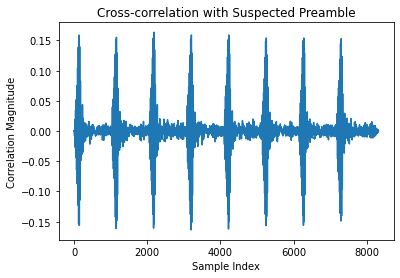

Peak correlation index: 2181
Peak correlation value: (0.15086453454179+0.06547788834234457j)
Synchronized signal start index: 2054


In [10]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [11]:
import numpy as np

# Given values
peak_index =2181
preamble_length = 128  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [-0.02218473+0.18805374j  0.18885337+0.15000527j  0.07919375+0.10032477j
  0.31402014+0.027485j    0.24426259-0.04097962j  0.20820408-0.1091841j
  0.17384988-0.16431837j -0.19293031-0.20622243j  0.00785234-0.21696587j
 -0.04366514-0.20873675j -0.09973254-0.16811991j -0.076861  -0.11155656j
 -0.24675291-0.03891071j -0.30437048+0.03210083j -0.10166366+0.10681759j
 -0.13783569+0.16798244j  0.09459474+0.2105831j   0.19645305+0.21807915j
  0.15082448+0.20471984j  0.06871764+0.15023772j  0.16417482+0.0899837j
  0.27824211+0.00943111j  0.43557105-0.06908733j  0.23267176-0.13996671j
  0.13009474-0.18670145j -0.00081873-0.21623047j  0.02266776-0.21529936j
 -0.12760728-0.18360955j -0.0459628 -0.12977888j -0.11713025-0.06067934j
 -0.1406038 +0.017872j   -0.21539521+0.09430128j -0.31445789+0.16110982j
  0.19740825+0.19999767j -0.24457295+0.21994334j  0.13021431+0.20905632j
  0.1612603 +0.17663628j  0.16136129+0.11097996j  0.26714047+0.03880411j
  0.23534359-0.04156315j  0.09622

In [12]:
preamble=suspected_preamble
data_input=data

In [13]:
preamble

array([-0.02218473+0.18805374j,  0.18885337+0.15000527j,
        0.07919375+0.10032477j,  0.31402014+0.027485j  ,
        0.24426259-0.04097962j,  0.20820408-0.1091841j ,
        0.17384988-0.16431837j, -0.19293031-0.20622243j,
        0.00785234-0.21696587j, -0.04366514-0.20873675j,
       -0.09973254-0.16811991j, -0.076861  -0.11155656j,
       -0.24675291-0.03891071j, -0.30437048+0.03210083j,
       -0.10166366+0.10681759j, -0.13783569+0.16798244j,
        0.09459474+0.2105831j ,  0.19645305+0.21807915j,
        0.15082448+0.20471984j,  0.06871764+0.15023772j,
        0.16417482+0.0899837j ,  0.27824211+0.00943111j,
        0.43557105-0.06908733j,  0.23267176-0.13996671j,
        0.13009474-0.18670145j, -0.00081873-0.21623047j,
        0.02266776-0.21529936j, -0.12760728-0.18360955j,
       -0.0459628 -0.12977888j, -0.11713025-0.06067934j,
       -0.1406038 +0.017872j  , -0.21539521+0.09430128j,
       -0.31445789+0.16110982j,  0.19740825+0.19999767j,
       -0.24457295+0.21994334j,

In [14]:
import numpy as np




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...


Most Common Synchronization Offset: 6156


/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py:26: ComplexWarning: Casting complex values to real discards the imaginary part


In [15]:
import numpy as np

def generate_pilot_sequence(preamble_array):
    # Extract the real and imaginary parts of the preamble array
    real_part = np.real(preamble_array)
    imag_part = np.imag(preamble_array)
    
    # Combine the real and imaginary parts to form the pilot sequence
    pilot_sequence = np.column_stack((real_part, imag_part)).flatten()
    
    return pilot_sequence

# Example usage
preamble = np.array([-0.02218473+0.18805374j,  0.18885337+0.15000527j,
        0.07919375+0.10032477j,  0.31402014+0.027485j  ,
        0.24426259-0.04097962j,  0.20820408-0.1091841j ,
        0.17384988-0.16431837j, -0.19293031-0.20622243j,
        0.00785234-0.21696587j, -0.04366514-0.20873675j,
       -0.09973254-0.16811991j, -0.076861  -0.11155656j,
       -0.24675291-0.03891071j, -0.30437048+0.03210083j,
       -0.10166366+0.10681759j, -0.13783569+0.16798244j,
        0.09459474+0.2105831j ,  0.19645305+0.21807915j,
        0.15082448+0.20471984j,  0.06871764+0.15023772j,
        0.16417482+0.0899837j ,  0.27824211+0.00943111j,
        0.43557105-0.06908733j,  0.23267176-0.13996671j,
        0.13009474-0.18670145j, -0.00081873-0.21623047j,
        0.02266776-0.21529936j, -0.12760728-0.18360955j,
       -0.0459628 -0.12977888j, -0.11713025-0.06067934j,
       -0.1406038 +0.017872j  , -0.21539521+0.09430128j,
       -0.31445789+0.16110982j,  0.19740825+0.19999767j,
       -0.24457295+0.21994334j,  0.13021431+0.20905632j,
        0.1612603 +0.17663628j,  0.16136129+0.11097996j,
        0.26714047+0.03880411j,  0.23534359-0.04156315j,
        0.09622962-0.10827813j, -0.00483657-0.17381295j,
        0.07503075-0.20643676j,  0.21273333-0.22502445j,
       -0.08687468-0.2013419j , -0.17956286-0.15961757j,
       -0.20117696-0.10135668j, -0.19439519-0.02629526j,
       -0.31354572+0.04827197j, -0.21776989+0.12587835j,
       -0.06844563+0.17712607j, -0.07407478+0.21150496j,
       -0.02972544+0.21522649j,  0.0578479 +0.19940073j,
       -0.04425188+0.16217827j,  0.30188041+0.10064537j,
        0.11997368+0.02882862j,  0.26275709-0.04717401j,
        0.08987818-0.11607203j,  0.15292851-0.17508537j,
       -0.06415148-0.21026066j,  0.08246019-0.21880435j,
        0.05564888-0.20635456j, -0.04679132-0.17224808j,
       -0.21273274-0.11201473j, -0.46263411-0.04137342j,
       -0.23940953+0.0263086j , -0.15234669+0.1005584j ,
       -0.03047592+0.15999741j,  0.01477158+0.19647698j,
       -0.06152773+0.22077672j, -0.06712959+0.2140982j ,
        0.16359732+0.1838394j ,  0.1382632 +0.13166747j,
        0.29951185+0.07226872j,  0.40904685+0.00188752j,
        0.25688274-0.07255363j,  0.26570838-0.13314065j,
        0.02474067-0.18557616j, -0.00975299-0.20943556j,
       -0.09824011-0.21618167j, -0.19487302-0.20133863j,
       -0.20314063-0.16391261j, -0.18917397-0.11156867j,
       -0.08718768-0.04114616j, -0.33354384+0.02951121j,
       -0.41315804+0.09548559j, -0.14363107+0.15537932j,
       -0.06156582+0.19559967j,  0.03052544+0.22105971j,
        0.07396226+0.22103518j,  0.10063676+0.19871774j,
        0.2437201 +0.14880836j,  0.16755816+0.09295157j,
        0.21810766+0.03105329j,  0.16454448-0.03823618j,
        0.05323478-0.10240476j,  0.15421333-0.15240295j,
        0.19751372-0.19556429j,  0.07962425-0.2140428j ,
        0.07755999-0.2151973j , -0.14983428-0.19674267j,
       -0.17703333-0.15235868j, -0.27014963-0.09821073j,
       -0.19786545-0.02577669j, -0.28039693+0.03539114j,
       -0.13098941+0.0948534j , -0.23320771+0.15334587j,
       -0.13331135+0.19003679j, -0.14087061+0.21588904j,
        0.01259756+0.21628142j,  0.12268043+0.1964087j ,
        0.09481419+0.16783192j,  0.05865846+0.11531272j,
        0.26789941+0.05749303j,  0.19365743-0.00883089j,
        0.12183745-0.07356401j,  0.08768767-0.1295786j ,
        0.02517474-0.17455852j,  0.12834877-0.20594007j,
        0.09439662-0.2178194j , -0.08149384-0.21172055j,
       -0.23498494-0.19087477j, -0.23990664-0.14482209j,
       -0.43094762-0.0963535j , -0.32416602-0.0350428j ,
       -0.21305782+0.03138795j, -0.15525982+0.09010259j])  # Replace with your actual preamble array
pilot_sequence = generate_pilot_sequence(preamble)
print(pilot_sequence)


[-0.02218473  0.18805374  0.18885337  0.15000527  0.07919375  0.10032477
  0.31402014  0.027485    0.24426259 -0.04097962  0.20820408 -0.1091841
  0.17384988 -0.16431837 -0.19293031 -0.20622243  0.00785234 -0.21696587
 -0.04366514 -0.20873675 -0.09973254 -0.16811991 -0.076861   -0.11155656
 -0.24675291 -0.03891071 -0.30437048  0.03210083 -0.10166366  0.10681759
 -0.13783569  0.16798244  0.09459474  0.2105831   0.19645305  0.21807915
  0.15082448  0.20471984  0.06871764  0.15023772  0.16417482  0.0899837
  0.27824211  0.00943111  0.43557105 -0.06908733  0.23267176 -0.13996671
  0.13009474 -0.18670145 -0.00081873 -0.21623047  0.02266776 -0.21529936
 -0.12760728 -0.18360955 -0.0459628  -0.12977888 -0.11713025 -0.06067934
 -0.1406038   0.017872   -0.21539521  0.09430128 -0.31445789  0.16110982
  0.19740825  0.19999767 -0.24457295  0.21994334  0.13021431  0.20905632
  0.1612603   0.17663628  0.16136129  0.11097996  0.26714047  0.03880411
  0.23534359 -0.04156315  0.09622962 -0.10827813 -0.0

In [16]:
pilot_sequence

array([-0.02218473,  0.18805374,  0.18885337,  0.15000527,  0.07919375,
        0.10032477,  0.31402014,  0.027485  ,  0.24426259, -0.04097962,
        0.20820408, -0.1091841 ,  0.17384988, -0.16431837, -0.19293031,
       -0.20622243,  0.00785234, -0.21696587, -0.04366514, -0.20873675,
       -0.09973254, -0.16811991, -0.076861  , -0.11155656, -0.24675291,
       -0.03891071, -0.30437048,  0.03210083, -0.10166366,  0.10681759,
       -0.13783569,  0.16798244,  0.09459474,  0.2105831 ,  0.19645305,
        0.21807915,  0.15082448,  0.20471984,  0.06871764,  0.15023772,
        0.16417482,  0.0899837 ,  0.27824211,  0.00943111,  0.43557105,
       -0.06908733,  0.23267176, -0.13996671,  0.13009474, -0.18670145,
       -0.00081873, -0.21623047,  0.02266776, -0.21529936, -0.12760728,
       -0.18360955, -0.0459628 , -0.12977888, -0.11713025, -0.06067934,
       -0.1406038 ,  0.017872  , -0.21539521,  0.09430128, -0.31445789,
        0.16110982,  0.19740825,  0.19999767, -0.24457295,  0.21

In [17]:
import numpy as np

# Define the pilot sequence (replace this with your actual pilot sequence)
#pilot = np.random.randn(len(preamble))
pilot=np.array([-0.02218473,  0.18805374,  0.18885337,  0.15000527,  0.07919375,
        0.10032477,  0.31402014,  0.027485  ,  0.24426259, -0.04097962,
        0.20820408, -0.1091841 ,  0.17384988, -0.16431837, -0.19293031,
       -0.20622243,  0.00785234, -0.21696587, -0.04366514, -0.20873675,
       -0.09973254, -0.16811991, -0.076861  , -0.11155656, -0.24675291,
       -0.03891071, -0.30437048,  0.03210083, -0.10166366,  0.10681759,
       -0.13783569,  0.16798244,  0.09459474,  0.2105831 ,  0.19645305,
        0.21807915,  0.15082448,  0.20471984,  0.06871764,  0.15023772,
        0.16417482,  0.0899837 ,  0.27824211,  0.00943111,  0.43557105,
       -0.06908733,  0.23267176, -0.13996671,  0.13009474, -0.18670145,
       -0.00081873, -0.21623047,  0.02266776, -0.21529936, -0.12760728,
       -0.18360955, -0.0459628 , -0.12977888, -0.11713025, -0.06067934,
       -0.1406038 ,  0.017872  , -0.21539521,  0.09430128, -0.31445789,
        0.16110982,  0.19740825,  0.19999767, -0.24457295,  0.21994334,
        0.13021431,  0.20905632,  0.1612603 ,  0.17663628,  0.16136129,
        0.11097996,  0.26714047,  0.03880411,  0.23534359, -0.04156315,
        0.09622962, -0.10827813, -0.00483657, -0.17381295,  0.07503075,
       -0.20643676,  0.21273333, -0.22502445, -0.08687468, -0.2013419 ,
       -0.17956286, -0.15961757, -0.20117696, -0.10135668, -0.19439519,
       -0.02629526, -0.31354572,  0.04827197, -0.21776989,  0.12587835,
       -0.06844563,  0.17712607, -0.07407478,  0.21150496, -0.02972544,
        0.21522649,  0.0578479 ,  0.19940073, -0.04425188,  0.16217827,
        0.30188041,  0.10064537,  0.11997368,  0.02882862,  0.26275709,
       -0.04717401,  0.08987818, -0.11607203,  0.15292851, -0.17508537,
       -0.06415148, -0.21026066,  0.08246019, -0.21880435,  0.05564888,
       -0.20635456, -0.04679132, -0.17224808, -0.21273274, -0.11201473,
       -0.46263411, -0.04137342, -0.23940953,  0.0263086 , -0.15234669,
        0.1005584 , -0.03047592,  0.15999741,  0.01477158,  0.19647698,
       -0.06152773,  0.22077672, -0.06712959,  0.2140982 ,  0.16359732,
        0.1838394 ,  0.1382632 ,  0.13166747,  0.29951185,  0.07226872,
        0.40904685,  0.00188752,  0.25688274, -0.07255363,  0.26570838,
       -0.13314065,  0.02474067, -0.18557616, -0.00975299, -0.20943556,
       -0.09824011, -0.21618167, -0.19487302, -0.20133863, -0.20314063,
       -0.16391261, -0.18917397, -0.11156867, -0.08718768, -0.04114616,
       -0.33354384,  0.02951121, -0.41315804,  0.09548559, -0.14363107,
        0.15537932, -0.06156582,  0.19559967,  0.03052544,  0.22105971,
        0.07396226,  0.22103518,  0.10063676,  0.19871774,  0.2437201 ,
        0.14880836,  0.16755816,  0.09295157,  0.21810766,  0.03105329,
        0.16454448, -0.03823618,  0.05323478, -0.10240476,  0.15421333,
       -0.15240295,  0.19751372, -0.19556429,  0.07962425, -0.2140428 ,
        0.07755999, -0.2151973 , -0.14983428, -0.19674267, -0.17703333,
       -0.15235868, -0.27014963, -0.09821073, -0.19786545, -0.02577669,
       -0.28039693,  0.03539114, -0.13098941,  0.0948534 , -0.23320771,
        0.15334587, -0.13331135,  0.19003679, -0.14087061,  0.21588904,
        0.01259756,  0.21628142,  0.12268043,  0.1964087 ,  0.09481419,
        0.16783192,  0.05865846,  0.11531272,  0.26789941,  0.05749303,
        0.19365743, -0.00883089,  0.12183745, -0.07356401,  0.08768767,
       -0.1295786 ,  0.02517474, -0.17455852,  0.12834877, -0.20594007,
        0.09439662, -0.2178194 , -0.08149384, -0.21172055, -0.23498494,
       -0.19087477, -0.23990664, -0.14482209, -0.43094762, -0.0963535 ,
       -0.32416602, -0.0350428 , -0.21305782,  0.03138795, -0.15525982,
        0.09010259])




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    
    # Carrier Frequency Offset (CFO) Compensation
    from scipy.fft import fft, ifft

    def estimate_cfo(signal, pilot):
        pilot_length = len(pilot)
        signal_pilot = signal[:pilot_length]
        phase_diff = np.angle(np.sum(signal_pilot * np.conj(pilot)))
        cfo = phase_diff / (2 * np.pi * pilot_length)
        return cfo

    def compensate_cfo(signal, cfo):
        n = np.arange(len(signal))
        return signal * np.exp(-1j * 2 * np.pi * cfo * n)

    # Example CFO compensation
    cfo_estimates = np.array([estimate_cfo(sig, pilot) for sig in synchronized_data])
    compensated_data = np.array([compensate_cfo(sig, cfo) for sig, cfo in zip(synchronized_data, cfo_estimates)])


/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py:81: ComplexWarning: Casting complex values to real discards the imaginary part


Most Common Synchronization Offset: 6156


In [23]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(compensated_data)
imaginary_part = np.imag(compensated_data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((compensated_data.shape[0],compensated_data.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [25]:
data_real_values.shape
data_real_values.shape[1]

2036

In [28]:
data_real_values.shape[1]

7170

In [42]:
data_real_values.shape

(5000, 2036, 2)

In [43]:
input_data=data_real_values

In [27]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [45]:
%pip install librosa


     |████████████████████████████████| 214 kB 27.3 MB/s eta 0:00:01
     |████████████████████████████████| 3.1 MB 106.9 MB/s eta 0:00:01
     |████████████████████████████████| 3.4 MB 34.4 MB/s eta 0:00:01
  Using cached packaging-21.3-py3-none-any.whl (40 kB)
     |████████████████████████████████| 56 kB 1.7 MB/s  eta 0:00:01
     |████████████████████████████████| 1.2 MB 28.2 MB/s eta 0:00:01
     |████████████████████████████████| 25.3 MB 66.3 MB/s eta 0:00:01
  Using cached importlib_resources-5.4.0-py3-none-any.whl (28 kB)
     |████████████████████████████████| 402 kB 86.3 MB/s eta 0:00:01
     |████████████████████████████████| 118 kB 95.2 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


/opt/conda/envs/project/lib/python3.6/site-packages/librosa/util/decorators.py:88: UserWarning: n_fft=2048 is too small for input signal of length=2036
  return f(*args, **kwargs)


ValueError: too many values to unpack (expected 2)

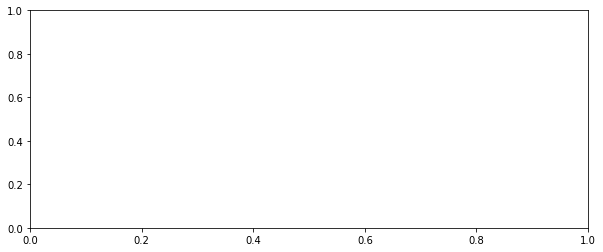

In [46]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Assuming your input data is stored in a variable called 'input_data'
# 'input_data' has shape (5000, 2036, 2)

# Initialize an empty array to store the spectrograms
spectrograms = []

# Iterate over each sample in the input data
for sample in input_data:
    # Transpose the sample to have the channels as the first dimension
    # librosa expects the channels to be in the first dimension
    sample = np.transpose(sample)

    # Compute the spectrogram using librosa's stft function
    # You may need to adjust parameters like n_fft, hop_length, and window size
    # to get the desired spectrogram resolution and time-frequency representation
    spectrogram = np.abs(librosa.stft(sample))

    # Append the computed spectrogram to the list
    spectrograms.append(spectrogram)

# Convert the list of spectrograms into a numpy array
spectrograms = np.array(spectrograms)

# Now 'spectrograms' contains the spectrogram representation of your input data
# It has shape (5000, num_freq_bins, num_time_bins)
# where num_freq_bins is determined by the number of FFT points and num_time_bins
# is determined by the hop length and length of your input data

# Optionally, you can visualize a spectrogram for one sample
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(spectrograms[0], ref=np.max), sr=44100, hop_length=512, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.show()


In [28]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [29]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape= (data_real_values.shape[1],2)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation='sigmoid'))

#cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
#cnn_model.summary()


In [ ]:
#Define the LSTM model
lstm_model = Sequential()
#lstm_model.add(LSTM(64, activation='relu', input_shape=(1, 8192)))
#lstm_model.add(Dense(128, activation='relu'))
#lstm_model.add(Dropout(0.5))
#lstm_model.add(Dense(1, activation='sigmoid'))


lstm_model.add(LSTM(64, activation='relu', input_shape= (data_real_values.shape[1],2)))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(10, activation='sigmoid'))

In [35]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=700, batch_size=32,
    callbacks=callbacks,
)




Train on 4000 samples, validate on 1000 samples
Epoch 1/700
4000/4000 [==============================] - 10s 2ms/step - loss: 2.0269 - acc: 0.1850 - val_loss: 1.4739 - val_acc: 0.2730
Epoch 2/700
4000/4000 [==============================] - 9s 2ms/step - loss: 1.3943 - acc: 0.3817 - val_loss: 1.1260 - val_acc: 0.5060
Epoch 3/700
4000/4000 [==============================] - 9s 2ms/step - loss: 1.2412 - acc: 0.4285 - val_loss: 0.8323 - val_acc: 0.6550
Epoch 4/700
4000/4000 [==============================] - 9s 2ms/step - loss: 1.0177 - acc: 0.5150 - val_loss: 0.6944 - val_acc: 0.6800
Epoch 5/700
4000/4000 [==============================] - 9s 2ms/step - loss: 0.9319 - acc: 0.5485 - val_loss: 0.7101 - val_acc: 0.6070
Epoch 6/700
4000/4000 [==============================] - 9s 2ms/step - loss: 0.8502 - acc: 0.5782 - val_loss: 0.8310 - val_acc: 0.4960
Epoch 7/700
4000/4000 [==============================] - 9s 2ms/step - loss: 0.8072 - acc: 0.6045 - val_loss: 0.7321 - val_acc: 0.6160
Epoch 

In [37]:
model_to_train.save('cnn5_model.h5')

In [38]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn5_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

acc: 90.30%


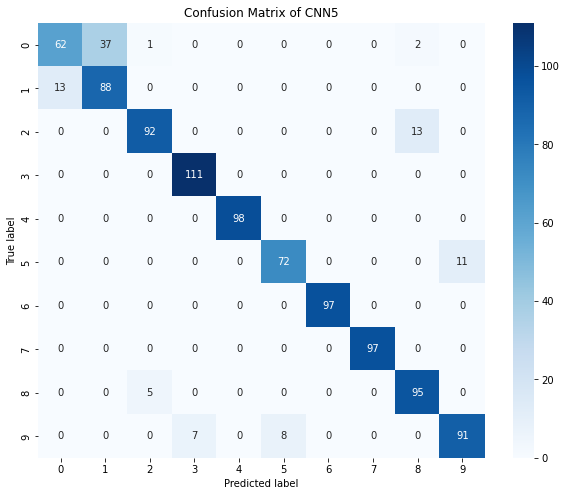

In [40]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN5')
plt.show()

In [41]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


Overall Precision: 0.9060429466233335
Overall Recall: 0.903
Overall F1-Score: 0.9014432389183715


In [41]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)




Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 229ms/step - accuracy: 0.1106 - loss: 2.8890 - val_accuracy: 0.2070 - val_loss: 1.8107 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.2559 - loss: 1.7618 - val_accuracy: 0.6610 - val_loss: 1.0686 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - accuracy: 0.4116 - loss: 1.2852 - val_accuracy: 0.6800 - val_loss: 0.8718 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 226ms/step - accuracy: 0.4779 - loss: 1.1161 - val_accuracy: 0.6790 - val_loss: 0.7374 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 224ms/step - accuracy: 0.5177 - loss: 1.0087 - val_accuracy: 0.7110 - val_loss: 0.7239 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 225ms/step - accuracy: 0.5336 - loss: 0.9280 - val_accuracy: 0.5970 - val_loss: 0.7236 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - accuracy: 0.6

In [42]:
model_to_train.save('cnn4_model.h5')

In [43]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn4_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 93.10%


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


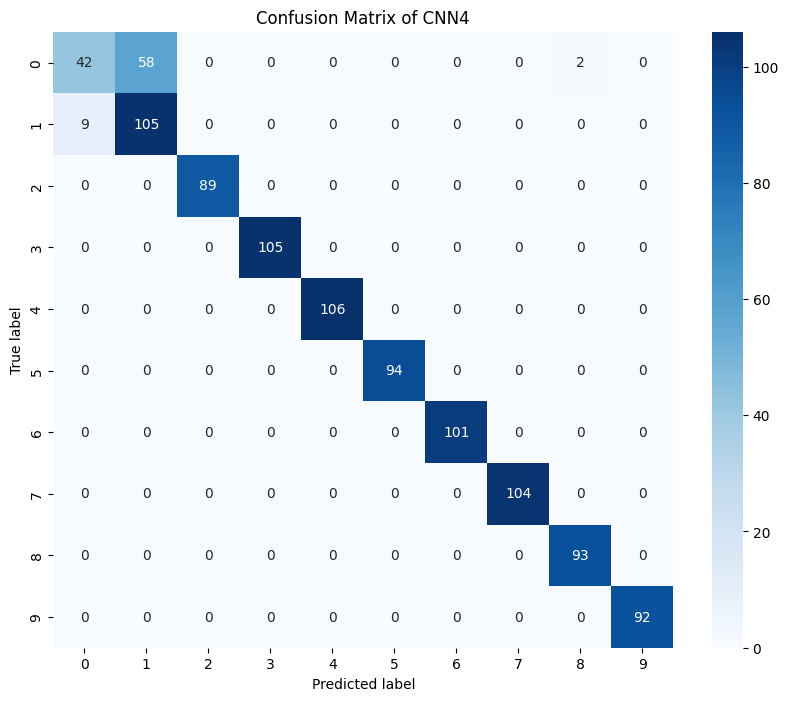

In [44]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN4')
plt.show()

In [45]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Overall Precision: 0.9394776880852437
Overall Recall: 0.931
Overall F1-Score: 0.9254366310776557


In [72]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=200, batch_size=32,
    callbacks=callbacks,
)




Epoch 1/200


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1098 - loss: 2.2431 - val_accuracy: 0.3470 - val_loss: 1.5872 - learning_rate: 0.0010
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3280 - loss: 1.4650 - val_accuracy: 0.7220 - val_loss: 0.8332 - learning_rate: 0.0010
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4932 - loss: 1.0337 - val_accuracy: 0.6770 - val_loss: 0.6712 - learning_rate: 0.0010
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5426 - loss: 0.9530 - val_accuracy: 0.8180 - val_loss: 0.5812 - learning_rate: 0.0010
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6068 - loss: 0.8168 - val_accuracy: 0.8110 - val_loss: 0.5324 - learning_rate: 0.0010
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6352 - loss: 0.7727 - val_accuracy: 0.7420 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6598 - loss: 0.7073 

In [74]:
model_to_train.save('cnn3_model.h5')

In [76]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn3_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 90.80%


In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN3')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


In [68]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=100, batch_size=32,
    callbacks=callbacks,
)




Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.1308 - loss: 2.1799 - val_accuracy: 0.3600 - val_loss: 1.3782 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.3660 - loss: 1.4218 - val_accuracy: 0.5670 - val_loss: 0.9274 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5199 - loss: 1.0206 - val_accuracy: 0.7080 - val_loss: 0.7077 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5911 - loss: 0.8450 - val_accuracy: 0.7390 - val_loss: 0.5675 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6705 - loss: 0.7159 - val_accuracy: 0.7080 - val_loss: 0.5371 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6253 - loss: 0.7686 - val_accuracy: 0.7440 - val_loss: 0.4924 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6987 - l

In [69]:
model_to_train.save('cnn2_model.h5')

In [70]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn2_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 89.60%


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


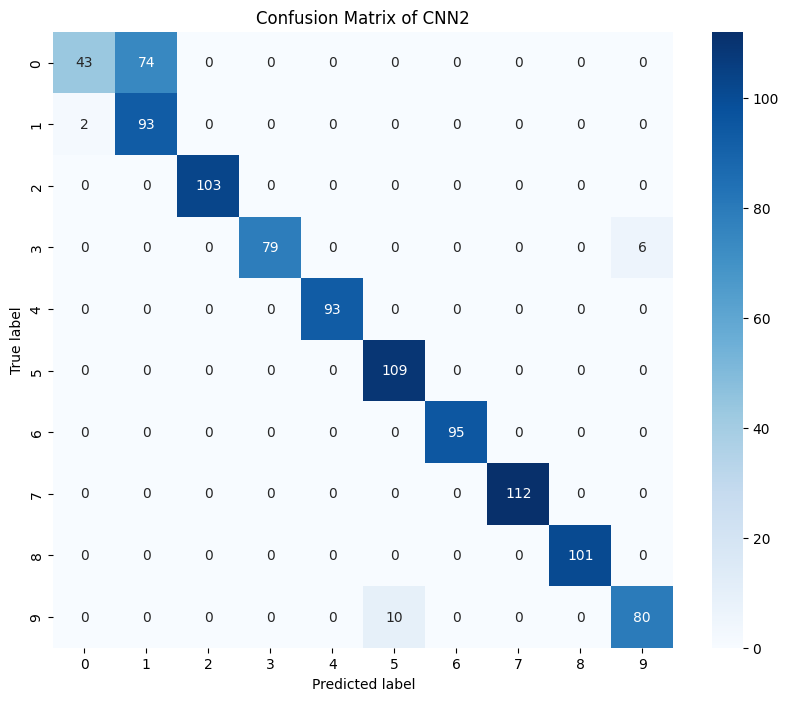

In [78]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN2')
plt.show()

In [65]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)




Epoch 1/50


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.1314 - loss: 2.2290 - val_accuracy: 0.3170 - val_loss: 1.4545 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4183 - loss: 1.2853 - val_accuracy: 0.6090 - val_loss: 0.7500 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5723 - loss: 0.8671 - val_accuracy: 0.6910 - val_loss: 0.6668 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6264 - loss: 0.7434 - val_accuracy: 0.6440 - val_loss: 0.6614 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7090 - loss: 0.6167 - val_accuracy: 0.8030 - val_loss: 0.4094 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6855 - loss: 0.6376 - val_accuracy: 0.8890 - val_loss: 0.3359 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7484 - loss: 0.5106 - val_

In [66]:
model_to_train.save('cnn1_model.h5')

In [67]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn1_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 88.80%


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


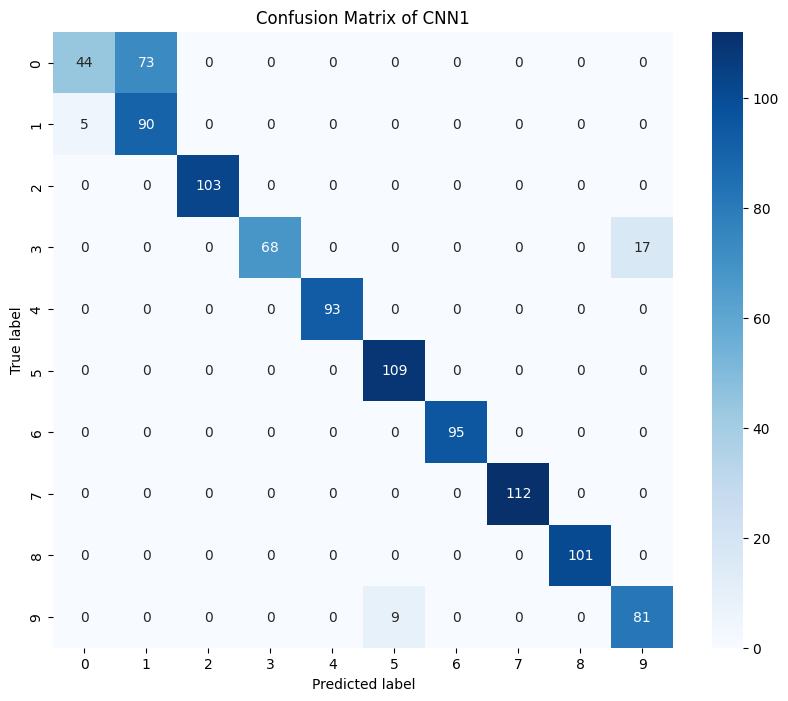

In [71]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN1')
plt.show()

In [ ]:
lstm_model = Sequential()

# Add an LSTM layer
lstm_model.add(LSTM(128, return_sequences=True, input_shape=(data_real_values.shape[1], 2)))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))

# Add another LSTM layer
lstm_model.add(LSTM(64))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))

# Add a Dense layer
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
lstm_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = lstm_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)


In [ ]:
model_to_train.save('lstm_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('lstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [40]:

from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Bidirectional, LSTM
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
Bilstm_model = Sequential()

# Add a Bidirectional LSTM layer
Bilstm_model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(data_real_values.shape[1], 2)))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.3))

# Add another Bidirectional LSTM layer
Bilstm_model.add(Bidirectional(LSTM(64)))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.3))

# Add a Dense layer
Bilstm_model.add(Dense(128, activation='relu'))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
Bilstm_model.add(Dense(10, activation='softmax'))

In [54]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
mlp_model = Sequential()

# Add Flatten layer to flatten the input
mlp_model.add(Flatten(input_shape=(data_real_values.shape[1], 2)))

# Add Dense layers
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.3))
mlp_model.add(Dense(64, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
mlp_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = mlp_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=500, batch_size=32,
    callbacks=callbacks,
)


Epoch 1/500


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1343 - loss: 2.7485 - val_accuracy: 0.1450 - val_loss: 2.3836 - learning_rate: 0.0010
Epoch 2/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2362 - loss: 2.0176 - val_accuracy: 0.2530 - val_loss: 1.7868 - learning_rate: 0.0010
Epoch 3/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2674 - loss: 1.7987 - val_accuracy: 0.3300 - val_loss: 1.4544 - learning_rate: 0.0010
Epoch 4/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3275 - loss: 1.6494 - val_accuracy: 0.3680 - val_loss: 1.3660 - learning_rate: 0.0010
Epoch 5/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3398 - loss: 1.5611 - val_accuracy: 0.3770 - val_loss: 1.3350 - learning_rate: 0.0010
Epoch 6/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3508 - loss: 1.4989 - val_accuracy: 0.4370 - val_loss: 1.2411 - learning_rate: 0.0010
Epoch 7/500
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3671 - loss: 1.4539 - val_

In [65]:
model_to_train.save('mlp_model.h5')

In [66]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('mlp_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 88.60%


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


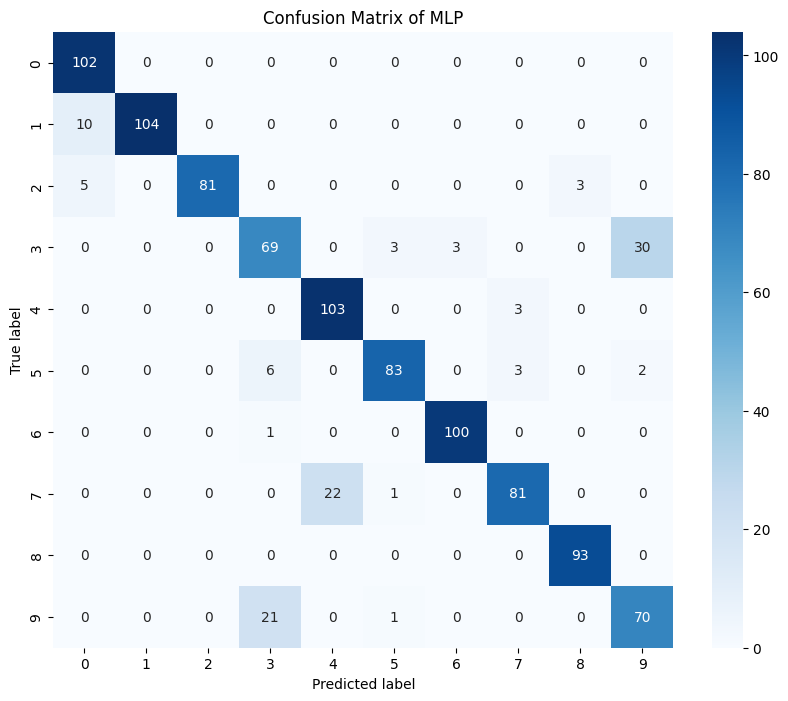

In [67]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of MLP')
plt.show()

In [68]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Overall Precision: 0.8907337330176941
Overall Recall: 0.886
Overall F1-Score: 0.8857377750976192


In [84]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
mlp1_model = Sequential()

# Add Flatten layer to flatten the input
mlp1_model.add(Flatten(input_shape=(data_real_values.shape[1], 2)))

# Add Dense layers
mlp1_model.add(Dense(128, activation='relu'))
mlp1_model.add(BatchNormalization())
mlp1_model.add(Dropout(0.3))
mlp1_model.add(Dense(64, activation='relu'))
mlp1_model.add(BatchNormalization())
mlp1_model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
mlp1_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = mlp1_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1535 - loss: 2.7273 - val_accuracy: 0.1300 - val_loss: 2.3951 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2361 - loss: 1.9954 - val_accuracy: 0.2500 - val_loss: 1.7888 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2723 - loss: 1.8058 - val_accuracy: 0.3760 - val_loss: 1.4602 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3161 - loss: 1.6520 - val_accuracy: 0.4240 - val_loss: 1.3461 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3132 - loss: 1.5793 - val_accuracy: 0.4240 - val_loss: 1.2810 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3440 - loss: 1.5004 - val_accuracy: 0.4050 - val_loss: 1.2237 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3693 - loss: 1.4403 - val_accura

In [85]:
model_to_train.save('mlp1_model.h5')

In [86]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('mlp1_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 79.00%


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


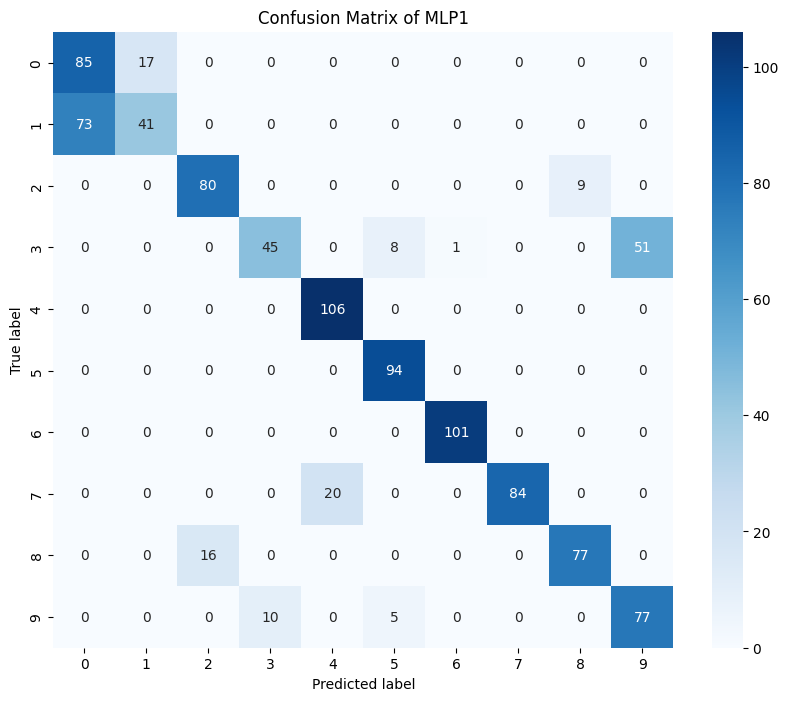

In [88]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of MLP1')
plt.show()

In [83]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Overall Precision: 0.7516237814849471
Overall Recall: 0.732
Overall F1-Score: 0.71137154901553


In [91]:
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, BatchNormalization, concatenate
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define input shape
input_shape = (data_real_values.shape[1], 2)

# Input layer
input_layer = Input(shape=input_shape)

# CNN layers
cnn_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu')(input_layer)
cnn_layer1 = MaxPooling1D(pool_size=2)(cnn_layer1)
cnn_layer2 = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_layer1)
cnn_layer2 = MaxPooling1D(pool_size=2)(cnn_layer2)
cnn_layer3 = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_layer2)
cnn_layer3 = MaxPooling1D(pool_size=2)(cnn_layer3)
cnn_output = Flatten()(cnn_layer3)

# MLP layers
mlp_input = Flatten()(input_layer)
mlp_layer1 = Dense(128, activation='relu')(mlp_input)
mlp_layer1 = BatchNormalization()(mlp_layer1)
mlp_layer1 = Dropout(0.3)(mlp_layer1)
mlp_layer2 = Dense(64, activation='relu')(mlp_layer1)
mlp_layer2 = BatchNormalization()(mlp_layer2)
mlp_layer2 = Dropout(0.3)(mlp_layer2)



# Concatenate the outputs of CNN, MLP, and LSTM
combined_layer = concatenate([cnn_output, mlp_layer2])

# Dense layers
dense_layer1 = Dense(128, activation='relu')(combined_layer)
dense_layer1 = BatchNormalization()(dense_layer1)
dense_layer1 = Dropout(0.3)(dense_layer1)
dense_layer2 = Dense(64, activation='relu')(dense_layer1)

# Output layer with 10 neurons for multi-class classification
output_layer = Dense(10, activation='softmax')(dense_layer2)

# Create the model
combined_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
#combined_model.summary()

# Fit the model
combined_model.fit(data_real_values_train, label_train, 
                   validation_data=(data_real_values_test, label_test),
                   epochs=50, batch_size=32,
                   callbacks=[ReduceLROnPlateau(factor=0.2, patience=5, min_lr=0.0001), EarlyStopping(patience=10, restore_best_weights=True)])


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 242ms/step - accuracy: 0.2378 - loss: 1.9509 - val_accuracy: 0.1050 - val_loss: 3.6400 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.3827 - loss: 1.4160 - val_accuracy: 0.1010 - val_loss: 4.2445 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 234ms/step - accuracy: 0.4161 - loss: 1.2970 - val_accuracy: 0.1350 - val_loss: 1.8546 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 235ms/step - accuracy: 0.4616 - loss: 1.1615 - val_accuracy: 0.1010 - val_loss: 4.7770 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - accuracy: 0.4450 - loss: 1.1393 - val_accuracy: 0.1170 - val_loss: 3.0711 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.5302 - loss: 0.9990 - val_accuracy: 0.2150 - val_loss: 9.4676 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 234ms/step - accuracy: 0.5

In [96]:
model_to_train.save('CNN_AND MLP_model.h5')

In [98]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('CNN_AND MLP_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 79.00%


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


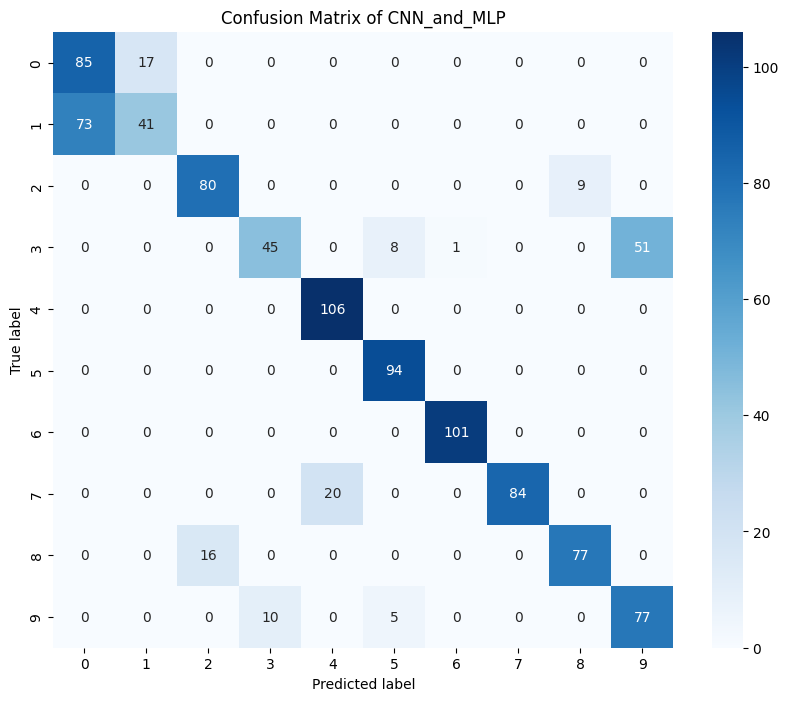

In [99]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN_and_MLP')
plt.show()

In [103]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 494ms/step
Overall Precision: 0.09478548611661927
Overall Recall: 0.108
Overall F1-Score: 0.07754363603921928


/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [100]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Dropout, Flatten, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
simple_rnn_model = Sequential()

# Add SimpleRNN layer
simple_rnn_model.add(SimpleRNN(128, input_shape=(data_real_values.shape[1], 2), return_sequences=True))
simple_rnn_model.add(BatchNormalization())
simple_rnn_model.add(Dropout(0.3))

# Add another SimpleRNN layer
simple_rnn_model.add(SimpleRNN(64))
simple_rnn_model.add(BatchNormalization())
simple_rnn_model.add(Dropout(0.3))

# Flatten the output
simple_rnn_model.add(Flatten())

# Add Dense layers
simple_rnn_model.add(Dense(128, activation='relu'))
simple_rnn_model.add(BatchNormalization())
simple_rnn_model.add(Dropout(0.3))
simple_rnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
simple_rnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = simple_rnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)



/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


KeyboardInterrupt: 

In [ ]:
model_to_train.save('simple_rnn_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('simple_rnn_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout, Flatten, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
gru_model = Sequential()

# Add GRU layer
gru_model.add(GRU(128, input_shape=(data_real_values.shape[1], 2), return_sequences=True))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.3))

# Add another GRU layer
gru_model.add(GRU(64))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.3))

# Flatten the output
gru_model.add(Flatten())

# Add Dense layers
gru_model.add(Dense(128, activation='relu'))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.3))
gru_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
gru_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = gru_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=100, batch_size=32,
    callbacks=callbacks,
)


In [ ]:
model_to_train.save('GRU_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('GRU_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, BatchNormalization, concatenate
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define input shape
input_shape = (1014, 2)

# Input layer
input_layer = Input(shape=input_shape)

# CNN layers
cnn_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu')(input_layer)
cnn_layer1 = MaxPooling1D(pool_size=2)(cnn_layer1)
cnn_layer2 = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_layer1)
cnn_layer2 = MaxPooling1D(pool_size=2)(cnn_layer2)
cnn_layer3 = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_layer2)
cnn_layer3 = MaxPooling1D(pool_size=2)(cnn_layer3)
cnn_output = Flatten()(cnn_layer3)

# MLP layers
mlp_input = Flatten()(input_layer)
mlp_layer1 = Dense(128, activation='relu')(mlp_input)
mlp_layer1 = BatchNormalization()(mlp_layer1)
mlp_layer1 = Dropout(0.3)(mlp_layer1)
mlp_layer2 = Dense(64, activation='relu')(mlp_layer1)
mlp_layer2 = BatchNormalization()(mlp_layer2)
mlp_layer2 = Dropout(0.3)(mlp_layer2)

# LSTM layers
lstm_layer1 = LSTM(128, return_sequences=True)(input_layer)
lstm_layer1 = BatchNormalization()(lstm_layer1)
lstm_layer1 = Dropout(0.3)(lstm_layer1)
lstm_layer2 = LSTM(64)(lstm_layer1)
lstm_layer2 = BatchNormalization()(lstm_layer2)
lstm_layer2 = Dropout(0.3)(lstm_layer2)

# Concatenate the outputs of CNN, MLP, and LSTM
combined_layer = concatenate([cnn_output, mlp_layer2, lstm_layer2])

# Dense layers
dense_layer1 = Dense(128, activation='relu')(combined_layer)
dense_layer1 = BatchNormalization()(dense_layer1)
dense_layer1 = Dropout(0.3)(dense_layer1)
dense_layer2 = Dense(64, activation='relu')(dense_layer1)

# Output layer with 10 neurons for multi-class classification
output_layer = Dense(10, activation='softmax')(dense_layer2)

# Create the model
combined_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
combined_model.summary()

# Fit the model
combined_model.fit(data_real_values_train, label_train, 
                   validation_data=(data_real_values_test, label_test),
                   epochs=100, batch_size=32,
                   callbacks=[ReduceLROnPlateau(factor=0.2, patience=5, min_lr=0.0001), EarlyStopping(patience=10, restore_best_weights=True)])


In [ ]:
model_to_train.save('cnn_mlp_lstm_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn_mlp_lstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, Bidirectional, BatchNormalization, concatenate
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define input shape
input_shape = (1014, 2)

# Input layer
input_layer = Input(shape=input_shape)

# CNN layers
cnn_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu')(input_layer)
cnn_layer1 = MaxPooling1D(pool_size=2)(cnn_layer1)
cnn_layer2 = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_layer1)
cnn_layer2 = MaxPooling1D(pool_size=2)(cnn_layer2)
cnn_layer3 = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_layer2)
cnn_layer3 = MaxPooling1D(pool_size=2)(cnn_layer3)
cnn_output = Flatten()(cnn_layer3)

# MLP layers
mlp_input = Flatten()(input_layer)
mlp_layer1 = Dense(128, activation='relu')(mlp_input)
mlp_layer1 = BatchNormalization()(mlp_layer1)
mlp_layer1 = Dropout(0.3)(mlp_layer1)
mlp_layer2 = Dense(64, activation='relu')(mlp_layer1)
mlp_layer2 = BatchNormalization()(mlp_layer2)
mlp_layer2 = Dropout(0.3)(mlp_layer2)

# BiLSTM layers
bilstm_layer = Bidirectional(LSTM(128, return_sequences=True))(input_layer)
bilstm_output = Bidirectional(LSTM(64))(bilstm_layer)

# Concatenate the outputs of CNN, MLP, and BiLSTM
combined_layer = concatenate([cnn_output, mlp_layer2, bilstm_output])

# Dense layers
dense_layer1 = Dense(128, activation='relu')(combined_layer)
dense_layer1 = BatchNormalization()(dense_layer1)
dense_layer1 = Dropout(0.3)(dense_layer1)
dense_layer2 = Dense(64, activation='relu')(dense_layer1)

# Output layer with 10 neurons for multi-class classification
output_layer = Dense(10, activation='softmax')(dense_layer2)

# Create the model
combined_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
combined_model.summary()

# Fit the model
combined_model.fit(data_real_values_train, label_train, 
                   validation_data=(data_real_values_test, label_test),
                   epochs=100, batch_size=32,
                   callbacks=[ReduceLROnPlateau(factor=0.2, patience=5, min_lr=0.0001), EarlyStopping(patience=10, restore_best_weights=True)])


In [ ]:
model_to_train.save('cnn_mlp_Bilstm_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn_mlp_Bilstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [41]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

#model_to_train = cnn_model
#model_to_train = lstm_model
model_to_train = Bilstm_model
#model_to_train = cnn_lstm_model
#model_to_train = mlp_model
#model_to_train = simpleRNN_model\n",
#model_to_train = gru_model\n",
#model_to_train=CNN_LSTM_model\n",
    
#loss1 = 'sparse_categorical_crossentropy'
#loss2 = 'binary_crossentropy'
#loss3 = keras.losses.BinaryFocalCrossentropy(),
    
#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/
    
#model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])
#train_history = model_to_train.fit(data_real_values_train, label_train, 
#                                       validation_data = (data_real_values_test, label_test),
#                                      epochs=50, batch_size=32)




callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
   # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#for model in models:
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                       validation_data = (data_real_values_test, label_test),
                                       epochs=70, batch_size=32,
                                       callbacks=callbacks,
                                       )

   


Epoch 1/70


AttributeError: module 'keras.src.backend' has no attribute 'convert_to_numpy'

In [59]:
model_to_train.save('Bilstm_model.h5')

In [60]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('Bilstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 95.80%


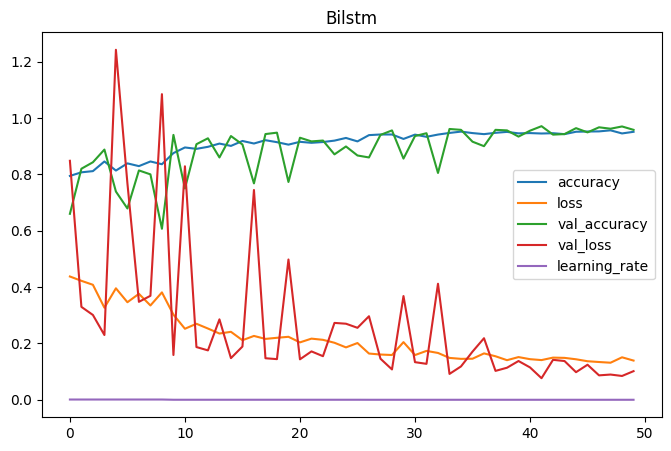

In [61]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'Bilstm')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [33]:
label_test.shape

(1000, 1)

In [35]:
data_real_values_test.shape

(1000, 1014, 2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 367ms/step


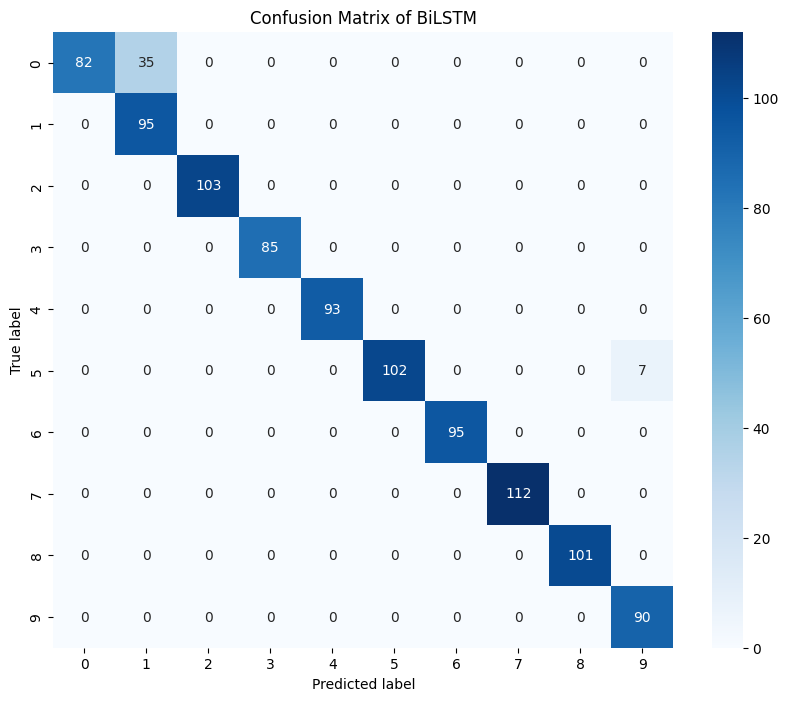

In [64]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [63]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


 1/32 ━━━━━━━━━━━━━━━━━━━━ 11s 361ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step
Overall Precision: 0.9679282315622523
Overall Recall: 0.958
Overall F1-Score: 0.957659235073691
